# Spotify Music Analysis Project

## Project Overview

This project explores a Spotify music dataset to identify trends and patterns in music characteristics and popularity. The analysis focuses on understanding how audio features such as danceability, energy, tempo, and valence relate to song popularity and genre distribution.

## Objectives

The main objectives of this project are:

* To clean and prepare the Spotify dataset for analysis.
* To perform exploratory data analysis (EDA) on song attributes.
* To identify the most common music genres in the dataset.
* To examine relationships between audio features and popularity.
* To create visualizations that communicate key insights effectively.
* To develop an interactive Tableau dashboard for data storytelling.

## Tools Used

* Python
* Pandas
* NumPy
* Matplotlib
* Seaborn
* Tableau
* GitHub

## Research Questions

1. Which music genres appear most frequently in the dataset?
2. What is the distribution of song popularity?
3. Is there a relationship between danceability and popularity?
4. Do energetic songs tend to be more popular?
5. Which genres have the highest average popularity?
6. How do audio features vary across different genres?

## Expected Outcomes

By the end of this project, I aim to gain insights into music trends and listener preferences while demonstrating skills in data cleaning, exploratory data analysis, data visualization, dashboard creation, and storytelling with data.


## Importing libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

### Loading the Dataset

In [2]:
df = pd.read_csv("spotifydataset.csv")

df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


### Data Exploration

In [3]:
df.shape

(114000, 21)

In [4]:
df.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [6]:
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [7]:
df.isnull().sum()

,0
Unnamed: 0,0
track_id,0
artists,1
album_name,1
track_name,1
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0


### Data Cleaning

The dataset contained a very small number of missing values in the `album_title` and `artist` columns (one missing value each). Since the number of missing records is extremely minimal compared to the overall dataset size, these rows were removed.

Dropping these rows ensures data consistency and avoids introducing artificial or incorrect values through imputation. This approach is appropriate for exploratory data analysis where maintaining data accuracy is more important than preserving every single record.

In [9]:
df = df.dropna(subset=['album_name', 'artists'])

In [11]:
df.isnull().sum()

,0
Unnamed: 0,0
track_id,0
artists,0
album_name,0
track_name,0
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0


In [12]:
df.drop_duplicates(inplace=True)

/tmp/ipykernel_3591/3006716147.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(inplace=True)


## Exploratory Data Analysis (EDA)
In this section, we analyze patterns in the dataset to understand relationships between audio features, genres, and song popularity.

###Most common genres

In [15]:
top_genres = df['track_genre'].value_counts().head(10)
top_genres

,count
track_genre,
acoustic,1000
afrobeat,1000
alt-rock,1000
alternative,1000
ambient,1000
anime,1000
black-metal,1000
bluegrass,1000
blues,1000


### Most popular songs

In [17]:
df[['track_name', 'artists', 'popularity']].sort_values(
    by='popularity', ascending=False
).head(10)

,track_name,artists,popularity
20001,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,100
81051,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,100
51664,"Quevedo: Bzrp Music Sessions, Vol. 52",Bizarrap;Quevedo,99
88410,La Bachata,Manuel Turizo,98
30003,I'm Good (Blue),David Guetta;Bebe Rexha,98
68303,La Bachata,Manuel Turizo,98
89411,La Bachata,Manuel Turizo,98
81210,I'm Good (Blue),David Guetta;Bebe Rexha,98
67356,La Bachata,Manuel Turizo,98
20008,I'm Good (Blue),David Guetta;Bebe Rexha,98


### Average popularity by genre

In [19]:
genre_popularity = df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False).head(10)
genre_popularity

,popularity
track_genre,
pop-film,59.283000
k-pop,56.952953
chill,53.651000
sad,52.379000
grunge,49.594000
indian,49.539000
anime,48.772000
emo,48.128000
sertanejo,47.866000


### Correlation

In [20]:
df.corr(numeric_only=True)

,Unnamed: 0,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
Unnamed: 0,1.000000,0.032146,-0.032738,-0.054735,0.003445,-0.055993,-0.005521,-0.027307,0.005110,-0.084952,0.076837,-0.070285,0.033641,0.053109,-0.025825,-0.021115
popularity,0.032146,1.000000,-0.007129,0.044078,0.035444,0.001053,-0.003847,0.050420,-0.013948,-0.044930,-0.025458,-0.095147,-0.005397,-0.040522,0.013212,0.031076
duration_ms,-0.032738,-0.007129,1.000000,-0.065270,-0.073435,0.058520,0.008123,-0.003475,-0.035581,-0.062605,-0.103770,0.124364,0.010308,-0.154464,0.024356,0.018229
explicit,-0.054735,0.044078,-0.065270,1.000000,0.122506,0.096954,0.004485,0.108587,-0.037216,0.307951,-0.094400,-0.103405,0.032547,-0.003378,-0.002815,0.038387
danceability,0.003445,0.035444,-0.073435,0.122506,1.000000,0.134325,0.036470,0.259076,-0.069224,0.108625,-0.171531,-0.185608,-0.131620,0.477347,-0.050448,0.207219
energy,-0.055993,0.001053,0.058520,0.096954,0.134325,1.000000,0.048007,0.761690,-0.078365,0.142508,-0.733908,-0.181880,0.184795,0.258937,0.247852,0.187127
key,-0.005521,-0.003847,0.008123,0.004485,0.036470,0.048007,1.000000,0.038591,-0.135911,0.020419,-0.040942,-0.006821,-0.001597,0.034099,0.010914,0.015064
loudness,-0.027307,0.050420,-0.003475,0.108587,0.259076,0.761690,0.038591,1.000000,-0.041768,0.060826,-0.589804,-0.433478,0.076897,0.279851,0.212447,0.191992
mode,0.005110,-0.013948,-0.035581,-0.037216,-0.069224,-0.078365,-0.135911,-0.041768,1.000000,-0.046535,0.095568,-0.049961,0.014004,0.021964,0.000572,-0.024090
speechiness,-0.084952,-0.044930,-0.062605,0.307951,0.108625,0.142508,0.020419,0.060826,-0.046535,1.000000,-0.002184,-0.089617,0.205218,0.036637,0.017274,-0.000011


### Popularity and Audio Feature Insights

In [26]:
# Explicit vs Popularity
print("Explicit vs Popularity Mean:")
print(df.groupby('explicit')['popularity'].mean())

# Features of top 1% tracks (popularity >= 80) vs all tracks
top_tracks = df[df['popularity'] >= 80]
all_tracks_mean = df[['danceability', 'energy', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence']].mean()
top_tracks_mean = top_tracks[['danceability', 'energy', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence']].mean()

comparison_df = pd.DataFrame({'All Tracks': all_tracks_mean, 'Top Tracks (Popularity >= 80)': top_tracks_mean})
print("\nAudio Feature Comparison:")
print(comparison_df)

Explicit vs Popularity Mean:
explicit
False    32.938207
True     36.454191
Name: popularity, dtype: float64

Audio Feature Comparison:
                  All Tracks  Top Tracks (Popularity >= 80)
danceability        0.566801                       0.648145
energy              0.641383                       0.682073
speechiness         0.084652                       0.081032
acousticness        0.314907                       0.188426
instrumentalness    0.156051                       0.024342
liveness            0.213554                       0.168381
valence             0.474066                       0.513800


## Data Visualizations

This section presents graphical analysis of the dataset to uncover patterns in music features, genre distribution, and song popularity.

### Popularity distribution

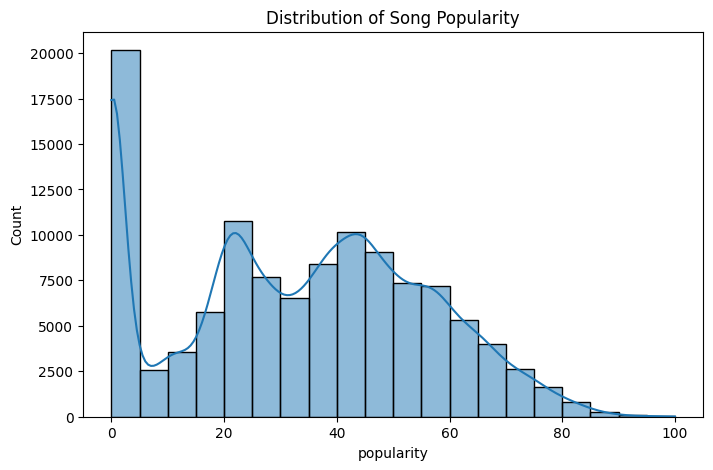

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['popularity'], bins=20, kde=True)
plt.title("Distribution of Song Popularity")
plt.show()

### Top Genres

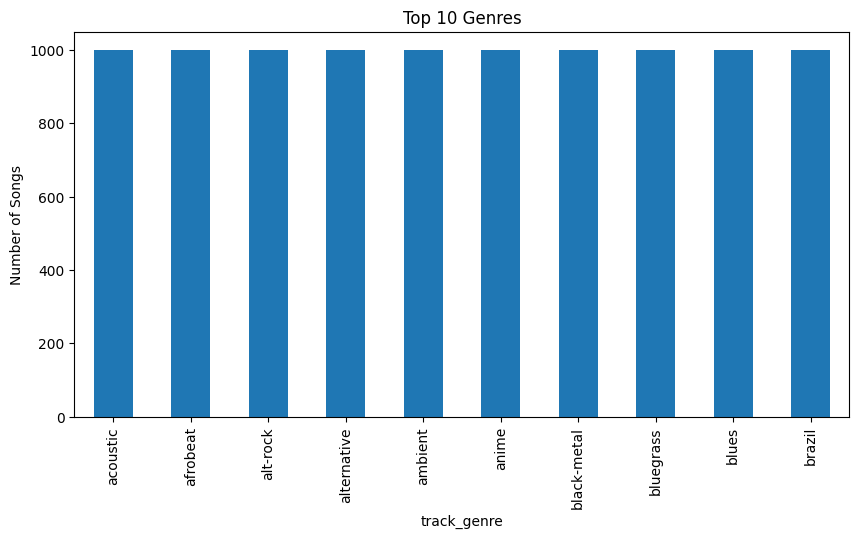

In [22]:
plt.figure(figsize=(10,5))
top_genres.plot(kind='bar')
plt.title("Top 10 Genres")
plt.ylabel("Number of Songs")
plt.show()

### Energy vs Danceability

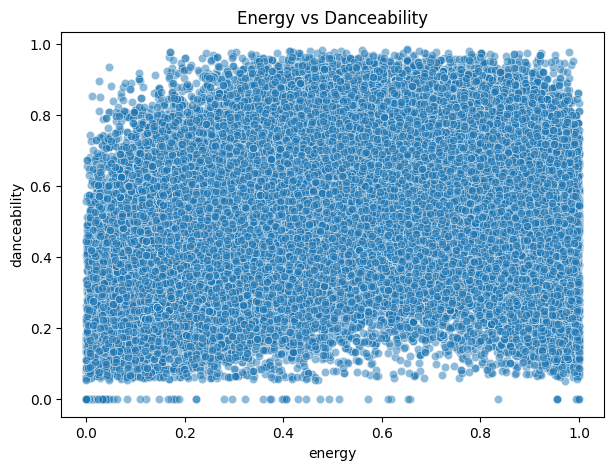

In [23]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='energy', y='danceability', alpha=0.5)
plt.title("Energy vs Danceability")
plt.show()

### Average popularity by genre

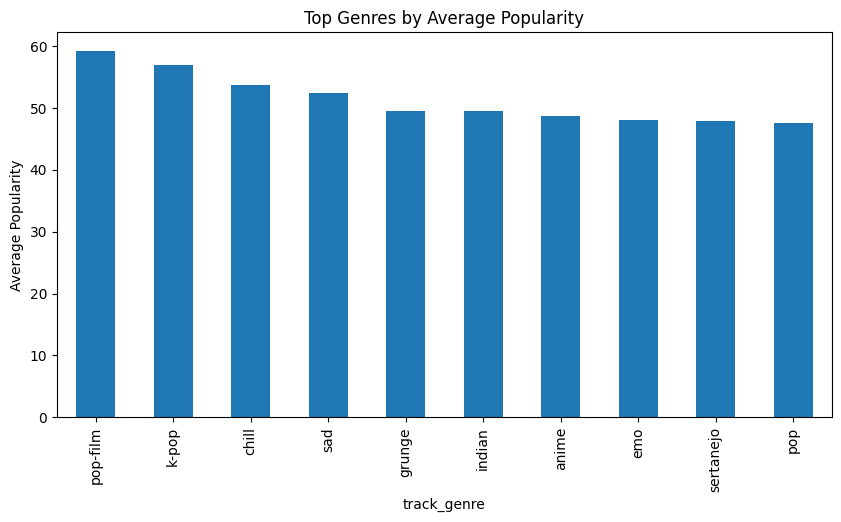

In [24]:
plt.figure(figsize=(10,5))
genre_popularity.plot(kind='bar')
plt.title("Top Genres by Average Popularity")
plt.ylabel("Average Popularity")
plt.show()

### Correlation heatmap

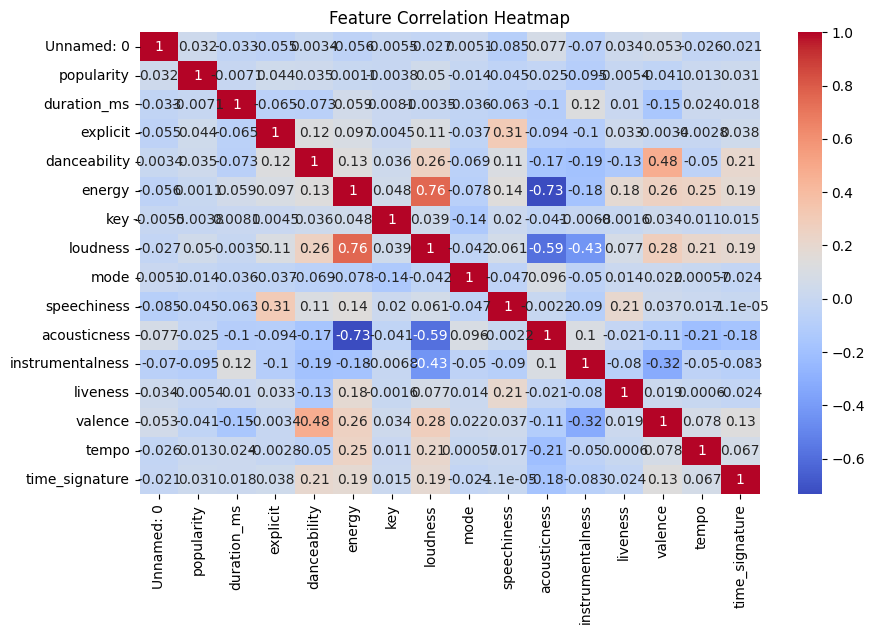

In [25]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

### Audio Feature Comparison Chart

/tmp/ipykernel_3591/17146124.py:30: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


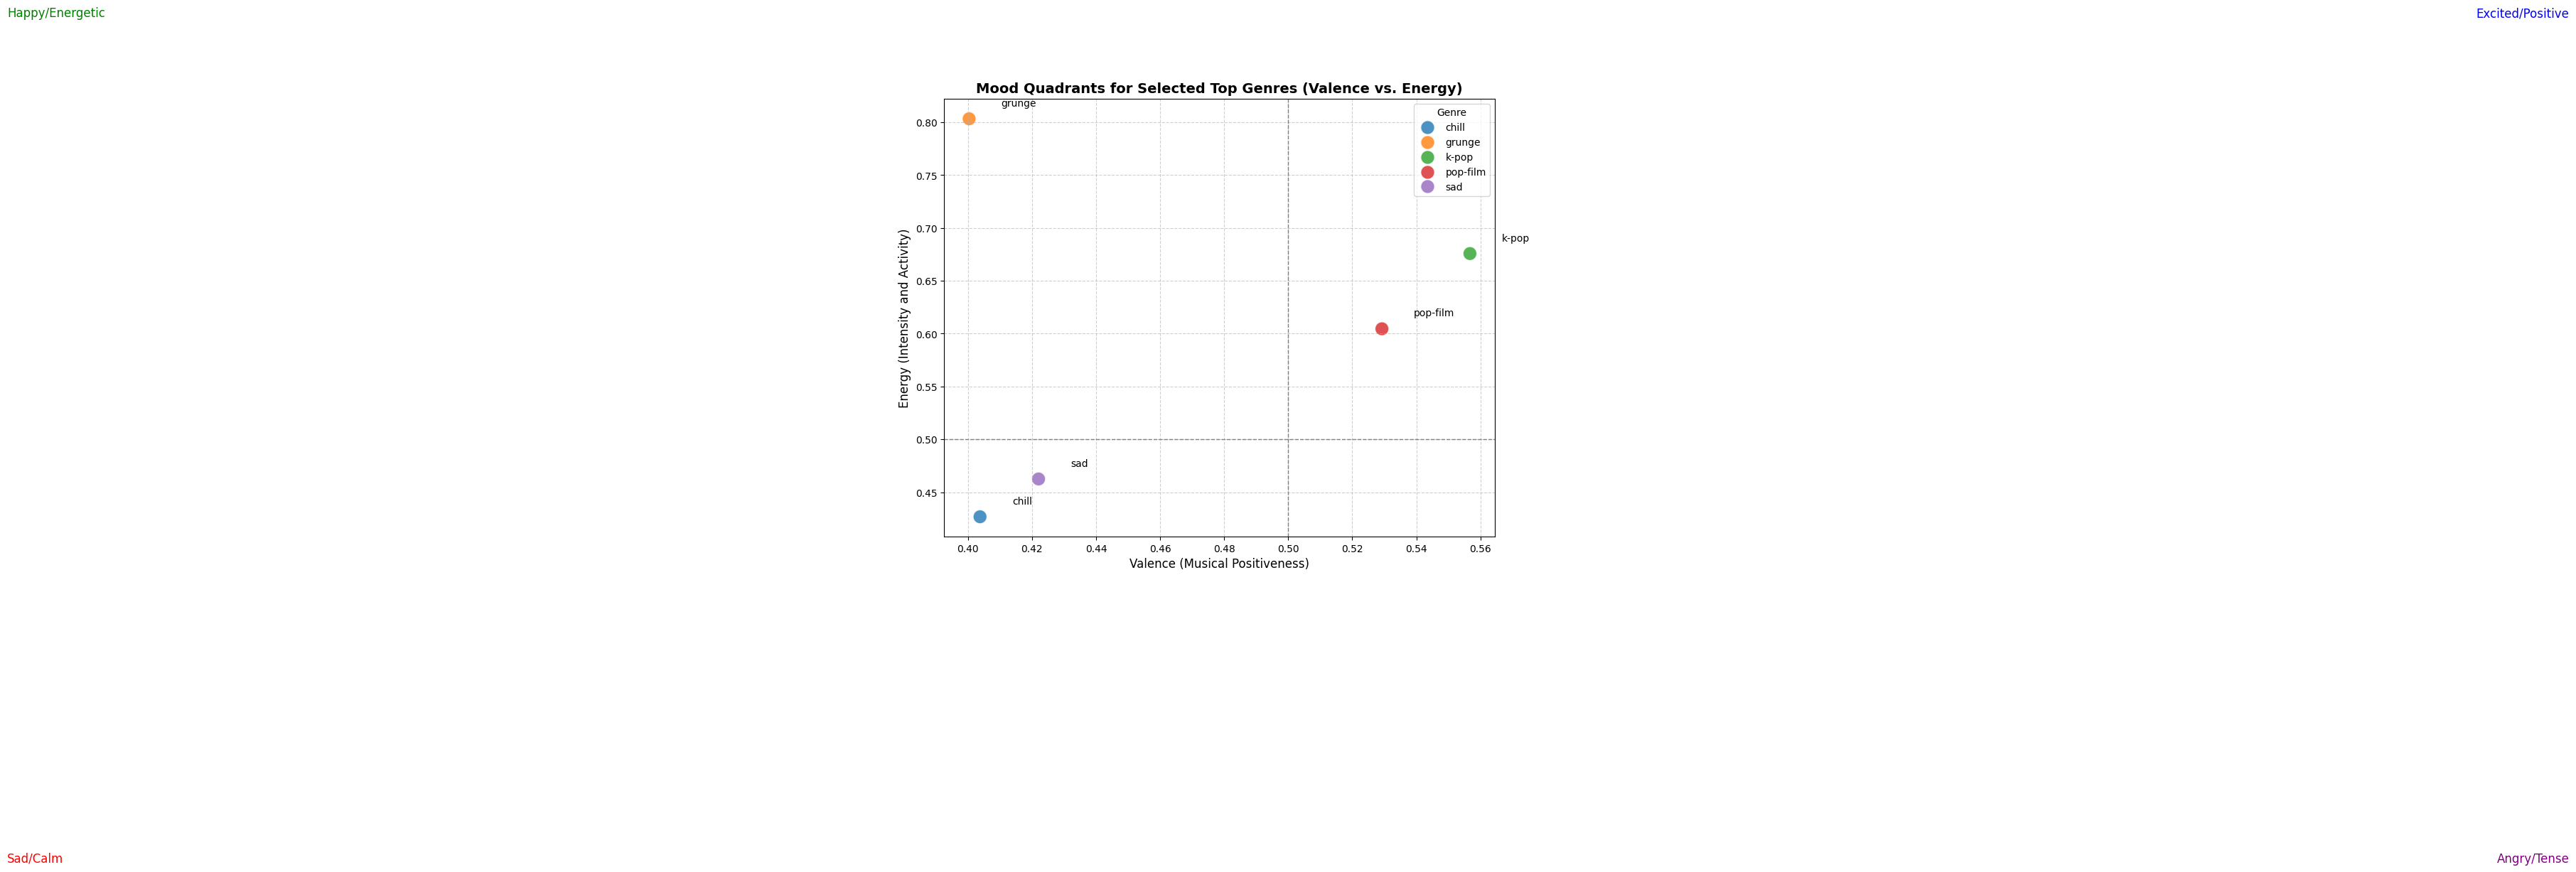

In [29]:
# 2. Mood Quadrants for top genres
# Let's pick 5 distinct genres to see where they sit

selected_genres = ['pop-film', 'k-pop', 'chill', 'sad', 'grunge']
mood_data = df[df['track_genre'].isin(selected_genres)].groupby('track_genre')[['valence', 'energy']].mean().reset_index()

plt.figure(figsize=(10, 8))
sns.scatterplot(data=mood_data, x='valence', y='energy', hue='track_genre', s=200, alpha=0.8)

# Add quadrant lines
plt.axvline(x=0.5, color='gray', linestyle='--', linewidth=1)
plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1)

# Add quadrant labels
plt.text(0.1, 0.9, 'Happy/Energetic', color='green', fontsize=12, horizontalalignment='left')
plt.text(0.9, 0.9, 'Excited/Positive', color='blue', fontsize=12, horizontalalignment='right')
plt.text(0.1, 0.1, 'Sad/Calm', color='red', fontsize=12, horizontalalignment='left')
plt.text(0.9, 0.1, 'Angry/Tense', color='purple', fontsize=12, horizontalalignment='right')

# Add genre names next to the points
for i, row in mood_data.iterrows():
    plt.text(row['valence'] + 0.01, row['energy'] + 0.01, row['track_genre'],
             horizontalalignment='left', verticalalignment='bottom', fontsize=10)

plt.title('Mood Quadrants for Selected Top Genres (Valence vs. Energy)', fontsize=14, fontweight='bold')
plt.xlabel('Valence (Musical Positiveness)', fontsize=12)
plt.ylabel('Energy (Intensity and Activity)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Genre')
plt.tight_layout()
plt.show()

### Top Artists

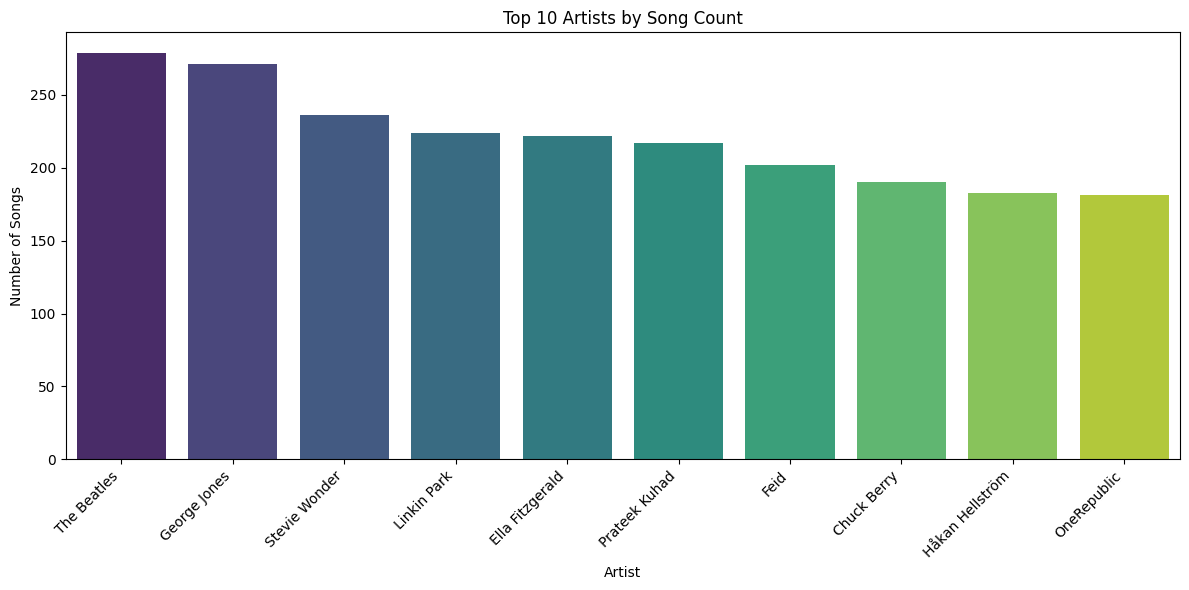

In [32]:
plt.figure(figsize=(12, 6))
sns.barplot(x=top_artists.index, y=top_artists.values, hue=top_artists.index, palette='viridis', legend=False)
plt.title('Top 10 Artists by Song Count')
plt.xlabel('Artist')
plt.ylabel('Number of Songs')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [33]:
top_albums = df['album_name'].value_counts().head(10)
display(top_albums)

,count
album_name,
Alternative Christmas 2022,195
Feliz Cumpleaños con Perreo,184
Metal,143
Halloween con perreito,123
Halloween Party 2022,115
The Complete Hank Williams,111
Fiesta portatil,110
Frescura y Perreo,106
Esto me suena a Farra,105


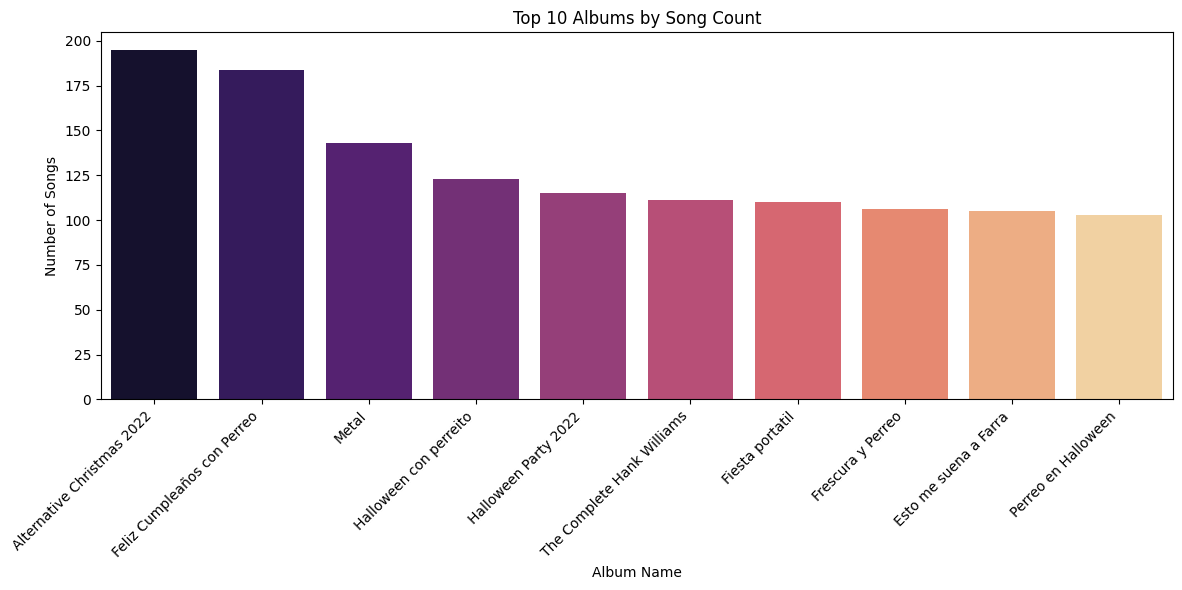

In [34]:
plt.figure(figsize=(12, 6))
sns.barplot(x=top_albums.index, y=top_albums.values, hue=top_albums.index, palette='magma', legend=False)
plt.title('Top 10 Albums by Song Count')
plt.xlabel('Album Name')
plt.ylabel('Number of Songs')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### How Audio Features Vary Across Different Genres

### Audio Feature Comparison: All Tracks vs. Top Tracks

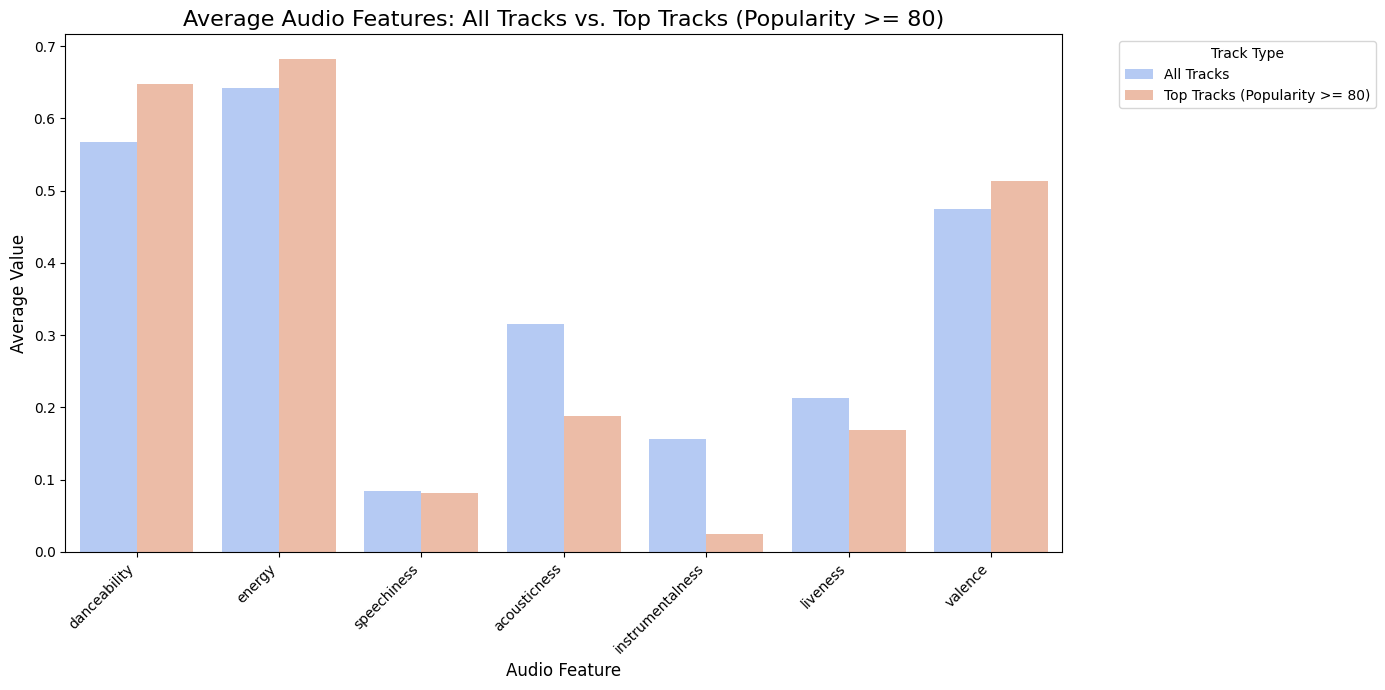

In [36]:
comparison_df_melted = comparison_df.reset_index().melt(id_vars='index', var_name='Track Type', value_name='Average Value')
comparison_df_melted.rename(columns={'index': 'Audio Feature'}, inplace=True)

plt.figure(figsize=(14, 7))
sns.barplot(x='Audio Feature', y='Average Value', hue='Track Type', data=comparison_df_melted, palette='coolwarm')
plt.title('Average Audio Features: All Tracks vs. Top Tracks (Popularity >= 80)', fontsize=16)
plt.xlabel('Audio Feature', fontsize=12)
plt.ylabel('Average Value', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Track Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

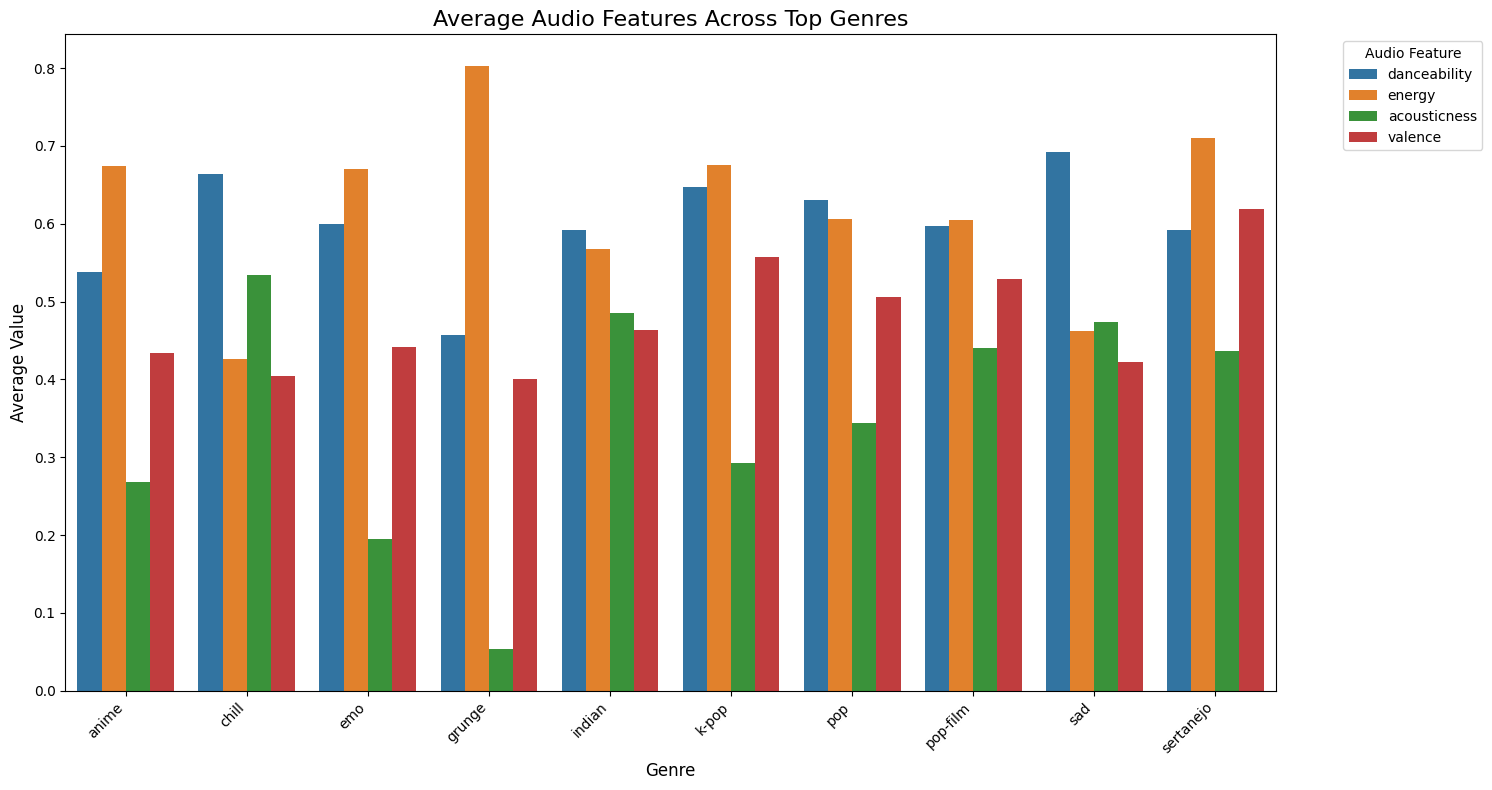

In [35]:
# Reusing genre_popularity to get the top genres by popularity
top_genres_names = genre_popularity.index.tolist()

# Filter the main DataFrame to include only these top genres
df_top_genres_features = df[df['track_genre'].isin(top_genres_names)]

# Calculate the mean of key audio features for these top genres
genre_audio_features = df_top_genres_features.groupby('track_genre')[['danceability', 'energy', 'acousticness', 'valence']].mean().reset_index()

# Melt the DataFrame for easier plotting with seaborn
genre_audio_features_melted = genre_audio_features.melt(id_vars='track_genre', var_name='Audio Feature', value_name='Average Value')

plt.figure(figsize=(15, 8))
sns.barplot(x='track_genre', y='Average Value', hue='Audio Feature', data=genre_audio_features_melted, palette='tab10')
plt.title('Average Audio Features Across Top Genres', fontsize=16)
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Average Value', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Audio Feature', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## KEY INSIGHTS FROM THE SPOTIFY DATASET
Song Popularity Distribution: The popularity distribution shows a common pattern where many songs have lower popularity scores, with a decreasing number of songs as popularity increases. There are a few highly popular outliers, but the majority of tracks are not top hits.

### Genre Distribution
The dataset contains an even distribution of the top genres, with each of the most frequent genres (e.g., acoustic, afrobeat, alt-rock) having a similar number of songs, suggesting a balanced representation of these genres.

### Audio Feature Relationships

Energy vs. Danceability: There appears to be a positive relationship between a song's energy and its danceability, meaning more energetic songs tend to be more danceable.

###Correlation Heatmap
Significant positive correlations were observed between energy and loudness, and to a lesser extent, danceability and valence. Conversely, acousticness showed negative correlations with energy and loudness, which is expected as highly acoustic tracks are typically less loud and energetic.

###Popular Genres
'pop-film', 'k-pop', and 'chill' emerged as the genres with the highest average popularity in the dataset.

Audio Features of Popular Songs: When comparing 'Top Tracks' (popularity >= 80) with 'All Tracks', popular songs tend to have higher danceability, energy, and valence, but lower acousticness and instrumentalness. This suggests that highly popular songs are often more upbeat, danceable, and less acoustic or instrumental-focused.

###Mood by Genre (Valence vs. Energy)
The mood quadrant analysis revealed distinct profiles for selected genres:

'grunge' songs are typically high in energy but low in valence (leaning towards angry/tense).
'k-pop' and 'pop-film' songs are generally high in both energy and valence (excited/positive).
'chill' and 'sad' genres naturally cluster in the lower energy and lower valence quadrants (sad/calm)

###Top Artists and Albums
 'The Beatles' were identified as the top artist by song count, and 'Alternative Christmas 2022' was the most frequently appearing album.

In [37]:
df.to_csv("spotify_cleaned.csv", index=False)